#V1,V2: 일반 CNN

In [ ]:
from pathlib import Path
import os
import re
import gc
import copy
import time
import json
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ============================================================
# 0. 경로/설정 (여기만 먼저 수정)
# ============================================================
XLS_PATH = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/2. 중심점상추 crops_coretest(2)_1088/candidate_metrics_bedall.xlsx")
IMG_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step2_roi_crop/roi_applied")
OUT_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# CSV 컬럼명
FILENAME_COL = "file_name"      # CSV 파일명 컬럼명. 필요시 "filename" 등으로 변경
BINARY_LABEL_COL = "core_lab_2class"   # 0/1 이진 라벨
MULTI_LABEL_COL = "core_strength"      # 0/1/2 다중 라벨

# 이미지
IMG_SIZE = 256
FILE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

# 학습
SEED = 42
N_SPLITS = 5
EPOCHS = 30
BATCH_SIZE = 16
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 5
MIXED_PRECISION = True
MAX_GRAD_NORM = 1.0

# backbone: 성능/안정성 고려
BACKBONE = "efficientnet_b0"   # 추천 유지. 필요시 mobilenet_v3_small, resnet18 로 변경 가능
USE_PRETRAINED = True

# 재시작/중간저장
SAVE_EVERY_EPOCH = True
RESUME_IF_EXISTS = True

# 클래스 불균형 보정
USE_CLASS_WEIGHT = True

In [ ]:
# ============================================================
# 1. 공통 유틸
# ============================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def now_str():
    return time.strftime("%Y-%m-%d %H:%M:%S")


def format_seconds(sec):
    sec = int(max(0, sec))
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


def write_log(log_path: Path, msg: str):
    print(msg)
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(msg + "\n")


def find_all_images(root: Path):
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in FILE_EXTS]


def build_image_index(root: Path):
    img_paths = find_all_images(root)
    idx = {}
    dup = {}
    for p in img_paths:
        name = p.name
        if name in idx:
            dup.setdefault(name, [idx[name]])
            dup[name].append(p)
        else:
            idx[name] = p
    return idx, dup, img_paths


def infer_device():
    return "cuda" if torch.cuda.is_available() else "cpu"


def get_model(backbone: str, num_classes: int, pretrained=True, dropout_p=0.3):
    backbone = backbone.lower()

    if backbone == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes)
        )
        return model

    if backbone == "mobilenet_v3_small":
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
        in_features = model.classifier[3].in_features
        model.classifier = nn.Sequential(
            model.classifier[0],
            model.classifier[1],
            model.classifier[2],
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes),
        )
        return model

    if backbone == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes),
        )
        return model

    raise ValueError(f"지원하지 않는 BACKBONE: {backbone}")


def get_transforms(img_size=256):
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.10, hue=0.02),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.92, 1.08)),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    valid_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return train_tf, valid_tf


# ============================================================
# 2. 데이터셋
# ============================================================
class LettuceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(row["img_path"])
        label = int(row["label"])

        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        return image, label, img_path.name

In [ ]:

# ============================================================
# 3. 학습/검증 함수
# ============================================================
def run_one_epoch(model, loader, criterion, optimizer, device, scaler=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            if scaler is not None and train:
                with torch.cuda.amp.autocast():
                    logits = model(images)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                if MAX_GRAD_NORM is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(images)
                loss = criterion(logits, labels)
                if train:
                    loss.backward()
                    if MAX_GRAD_NORM is not None:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                    optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        running_loss += loss.item() * images.size(0)
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / max(1, len(loader.dataset))
    return epoch_loss, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def calc_metrics(y_true, y_pred, y_prob, num_classes, task_name):
    metrics = {}
    metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
    metrics["f1_macro"] = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    metrics["f1_weighted"] = float(f1_score(y_true, y_pred, average="weighted", zero_division=0))

    if num_classes == 2:
        # positive class = 1
        try:
            metrics["auc"] = float(roc_auc_score(y_true, y_prob[:, 1]))
        except Exception:
            metrics["auc"] = np.nan
    else:
        try:
            metrics["auc_ovr_macro"] = float(roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro"))
        except Exception:
            metrics["auc_ovr_macro"] = np.nan

    metrics["confusion_matrix"] = confusion_matrix(y_true, y_pred).tolist()
    metrics["classification_report"] = classification_report(y_true, y_pred, zero_division=0)
    return metrics


def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


# ============================================================
# 4. 데이터 준비
# ============================================================
def prepare_dataframe(csv_path, img_root, filename_col, label_col, task_name, log_path):
    # Check file extension and read accordingly
    if str(csv_path).lower().endswith('.xlsx'):
        df = pd.read_excel(csv_path)
    else:
        df = pd.read_csv(csv_path)

    if filename_col not in df.columns:
        raise ValueError(f"CSV에 {filename_col} 컬럼이 없습니다. 현재 컬럼: {list(df.columns)}")
    if label_col not in df.columns:
        raise ValueError(f"CSV에 {label_col} 컬럼이 없습니다. 현재 컬럼: {list(df.columns)}")

    img_index, dup, img_list = build_image_index(img_root)
    write_log(log_path, f"[이미지 인덱싱] 전체 이미지 수: {len(img_list):,}")
    write_log(log_path, f"[이미지 인덱싱] 중복 파일명 수: {len(dup):,}")

    work = df[[filename_col, label_col]].copy()
    work = work.rename(columns={filename_col: "file_name", label_col: "label"})
    work = work.dropna(subset=["file_name", "label"]).copy()
    work["file_name"] = work["file_name"].astype(str)
    # Strip the '__core_candidate' suffix from the filenames in the DataFrame
    work['file_name'] = work['file_name'].str.replace('__core_candidate', '', regex=False)
    work["label"] = work["label"].astype(int)

    keep_rows = []
    missing = []

    for _, row in work.iterrows():
        fname = row["file_name"]
        if fname in img_index:
            keep_rows.append({
                "file_name": fname,
                "label": int(row["label"]),
                "img_path": str(img_index[fname]),
            })
        else:
            missing.append(fname)

    out_df = pd.DataFrame(keep_rows)

    write_log(log_path, f"[{task_name}] CSV 행 수(결측 제거 후): {len(work):,}")
    write_log(log_path, f"[{task_name}] 매칭 성공 수: {len(out_df):,}")
    write_log(log_path, f"[{task_name}] 매칭 실패 수: {len(missing):,}")

    if len(missing) > 0:
        miss_path = OUT_ROOT / f"missing_{task_name}.txt"
        with open(miss_path, "w", encoding="utf-8") as f:
            for x in missing:
                f.write(str(x) + "\n")
        write_log(log_path, f"[{task_name}] 매칭 실패 파일명 저장: {miss_path}")

    if len(out_df) == 0:
        raise ValueError(f"[{task_name}] 매칭된 데이터가 없습니다.")

    cls_count = out_df["label"].value_counts().sort_index().to_dict()
    write_log(log_path, f"[{task_name}] 클래스 분포: {cls_count}")

    return out_df


# ============================================================
# 5. fold 학습
# ============================================================
def train_cv_task(df_all, task_name, num_classes, out_dir, device, log_path):
    out_dir.mkdir(parents=True, exist_ok=True)
    train_tf, valid_tf = get_transforms(IMG_SIZE)

    X = df_all["img_path"].values
    y = df_all["label"].values

    # Determine n_splits dynamically based on minimum class count
    class_counts = df_all["label"].value_counts()
    min_samples_in_class = class_counts.min() if not class_counts.empty else 0

    if min_samples_in_class == 0:
        raise ValueError(f"[{task_name}] Cannot perform cross-validation: No samples available in some classes. Class distribution: {class_counts.to_dict()}")

    effective_n_splits = min(N_SPLITS, min_samples_in_class)

    if effective_n_splits < N_SPLITS:
        write_log(log_path, f"[{task_name}] Warning: N_SPLITS reduced from {N_SPLITS} to {effective_n_splits} due to insufficient samples in some classes (min samples: {min_samples_in_class}).")

    if effective_n_splits < 2: # StratifiedKFold requires at least 2 splits
        write_log(log_path, f"[{task_name}] Skipping cross-validation as effective N_SPLITS is {effective_n_splits}. StratifiedKFold requires at least 2 splits. Consider increasing dataset size for classes with few samples.")
        return pd.DataFrame() # Return empty DataFrame as no meaningful CV can be performed

    skf = StratifiedKFold(n_splits=effective_n_splits, shuffle=True, random_state=SEED)

    fold_results = []
    total_cv_start = time.time()

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        fold_start = time.time()
        fold_dir = out_dir / f"fold_{fold}"
        fold_dir.mkdir(parents=True, exist_ok=True)
        ckpt_path = fold_dir / "best_model.pt"
        state_path = fold_dir / "resume_state.pt"
        result_path = fold_dir / "fold_result.json"

        train_df = df_all.iloc[tr_idx].reset_index(drop=True)
        valid_df = df_all.iloc[va_idx].reset_index(drop=True)

        write_log(log_path, "-" * 80)
        write_log(log_path, f"[{task_name}] Fold {fold}/{effective_n_splits} 시작 | train={len(train_df)} val={len(valid_df)}")
        write_log(log_path, f"[{task_name}] Fold {fold} train 분포: {train_df['label'].value_counts().sort_index().to_dict()}")
        write_log(log_path, f"[{task_name}] Fold {fold} valid 분포: {valid_df['label'].value_counts().sort_index().to_dict()}")

        train_ds = LettuceDataset(train_df, transform=train_tf)
        valid_ds = LettuceDataset(valid_df, transform=valid_tf)

        train_loader = DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            drop_last=False,
        )
        valid_loader = DataLoader(
            valid_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            drop_last=False,
        )

        model = get_model(BACKBONE, num_classes=num_classes, pretrained=USE_PRETRAINED, dropout_p=0.3).to(device)

        # class weight
        class_weights = None
        if USE_CLASS_WEIGHT:
            counts = train_df["label"].value_counts().sort_index().to_dict()
            weight_list = []
            total = len(train_df)
            for c in range(num_classes):
                cnt = counts.get(c, 1)
                weight_list.append(total / (num_classes * cnt))
            class_weights = torch.tensor(weight_list, dtype=torch.float32, device=device)
            write_log(log_path, f"[{task_name}] Fold {fold} class_weights: {weight_list}")

        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
        scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda" and MIXED_PRECISION))

        start_epoch = 1
        best_score = -np.inf
        best_payload = None
        no_improve = 0

        if RESUME_IF_EXISTS and state_path.exists():
            state = torch.load(state_path, map_location=device)
            model.load_state_dict(state["model_state"])
            optimizer.load_state_dict(state["optimizer_state"])
            scheduler.load_state_dict(state["scheduler_state"])
            if state.get("scaler_state") is not None and scaler is not None:
                scaler.load_state_dict(state["scaler_state"])
            start_epoch = state["epoch"] + 1
            best_score = state["best_score"]
            no_improve = state["no_improve"]
            write_log(log_path, f"[{task_name}] Fold {fold} resume from epoch {start_epoch}")

        for epoch in range(start_epoch, EPOCHS + 1):
            ep_start = time.time()

            tr_loss, tr_y, tr_pred, tr_prob = run_one_epoch(
                model, train_loader, criterion, optimizer, device, scaler=scaler, train=True
            )
            va_loss, va_y, va_pred, va_prob = run_one_epoch(
                model, valid_loader, criterion, optimizer, device, scaler=None, train=False
            )

            train_metrics = calc_metrics(tr_y, tr_pred, tr_prob, num_classes, task_name)
            valid_metrics = calc_metrics(va_y, va_pred, va_prob, num_classes, task_name)

            # 선택 기준
            valid_score = valid_metrics.get("auc", valid_metrics.get("auc_ovr_macro", valid_metrics["f1_macro"]))
            if np.isnan(valid_score):
                valid_score = valid_metrics["f1_macro"]

            scheduler.step(valid_score)

            ep_elapsed = time.time() - ep_start
            write_log(
                log_path,
                f"[{task_name}] Fold {fold} Epoch {epoch:02d}/{EPOCHS} | "
                f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f} | "
                f"train_acc={train_metrics['accuracy']:.4f} val_acc={valid_metrics['accuracy']:.4f} | "
                f"train_f1m={train_metrics['f1_macro']:.4f} val_f1m={valid_metrics['f1_macro']:.4f} | "
                f"val_score={valid_score:.4f} | time={format_seconds(ep_elapsed)}"
            )

            if valid_score > best_score:
                best_score = valid_score
                no_improve = 0
                best_payload = {
                    "epoch": epoch,
                    "best_score": float(best_score),
                    "train_loss": float(tr_loss),
                    "valid_loss": float(va_loss),
                    "train_metrics": train_metrics,
                    "valid_metrics": valid_metrics,
                }
                torch.save({
                    "model_state": model.state_dict(),
                    "best_payload": best_payload,
                }, ckpt_path)
                write_log(log_path, f"[{task_name}] Fold {fold} best 갱신 -> {ckpt_path}")
            else:
                no_improve += 1

            if SAVE_EVERY_EPOCH:
                torch.save({
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "scheduler_state": scheduler.state_dict(),
                    "scaler_state": scaler.state_dict() if scaler is not None else None,
                    "best_score": best_score,
                    "no_improve": no_improve,
                }, state_path)

            if no_improve >= PATIENCE:
                write_log(log_path, f"[{task_name}] Fold {fold} early stopping (patience={PATIENCE})")
                break

        # best model 로드 후 fold 결과 저장
        saved = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(saved["model_state"])
        best_payload = saved["best_payload"]
        save_json(best_payload, result_path)

        fold_results.append({
            "fold": fold,
            **best_payload,
            "elapsed_sec": time.time() - fold_start,
        })

        write_log(log_path, f"[{task_name}] Fold {fold} 완료 | best_score={best_payload['best_score']:.4f} | fold_time={format_seconds(time.time()-fold_start)}")

        del model, train_loader, valid_loader, train_ds, valid_ds
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # CV 요약
    summary_rows = []
    for x in fold_results:
        row = {
            "fold": x["fold"],
            "epoch": x["epoch"],
            "best_score": x["best_score"],
            "train_loss": x["train_loss"],
            "valid_loss": x["valid_loss"],
            "train_acc": x["train_metrics"]["accuracy"],
            "valid_acc": x["valid_metrics"]["accuracy"],
            "train_f1_macro": x["train_metrics"]["f1_macro"],
            "valid_f1_macro": x["valid_metrics"]["f1_macro"],
            "elapsed_sec": x["elapsed_sec"],
        }
        if num_classes == 2:
            row["valid_auc"] = x["valid_metrics"].get("auc", np.nan)
        else:
            row["valid_auc_ovr_macro"] = x["valid_metrics"].get("auc_ovr_macro", np.nan)
        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    summary_csv = out_dir / f"cv_summary_{task_name}.csv"
    summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

    mean_dict = summary_df.mean(numeric_only=True).to_dict()
    save_json(mean_dict, out_dir / f"cv_mean_{task_name}.json")

    write_log(log_path, "=" * 80)
    write_log(log_path, f"[{task_name}] CV 완료 | 총 시간={format_seconds(time.time() - total_cv_start)}")
    write_log(log_path, f"[{task_name}] 요약 CSV 저장: {summary_csv}")
    write_log(log_path, f"[{task_name}] 평균 성능: {mean_dict}")

    return summary_df

In [ ]:


# ============================================================
# 6. 메인
# ============================================================
def main():
    seed_everything(SEED)
    device = infer_device()

    run_name = f"run_{time.strftime('%Y%m%d_%H%M%S')}_{BACKBONE}_img{IMG_SIZE}"
    run_dir = OUT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    log_path = run_dir / "train_log.txt"

    write_log(log_path, "=" * 100)
    write_log(log_path, f"[START] {now_str()}")
    write_log(log_path, f"CSV_PATH   : {XLS_PATH}")
    write_log(log_path, f"IMG_ROOT   : {IMG_ROOT}")
    write_log(log_path, f"OUT_ROOT   : {run_dir}")
    write_log(log_path, f"DEVICE     : {device}")
    write_log(log_path, f"BACKBONE   : {BACKBONE}")
    write_log(log_path, f"IMG_SIZE   : {IMG_SIZE}")
    write_log(log_path, f"BATCH_SIZE : {BATCH_SIZE}")
    write_log(log_path, f"EPOCHS     : {EPOCHS}")
    write_log(log_path, f"N_SPLITS   : {N_SPLITS}")
    write_log(log_path, f"LR         : {LR}")
    write_log(log_path, f"WEIGHT_DECAY: {WEIGHT_DECAY}")
    write_log(log_path, f"DROPOUT_P  : 0.3")

    # ----------------------
    # 실험 1: binary
    # ----------------------
    binary_df = prepare_dataframe(
        csv_path=XLS_PATH,
        img_root=IMG_ROOT,
        filename_col=FILENAME_COL,
        label_col=BINARY_LABEL_COL,
        task_name="binary_heading",
        log_path=log_path,
    )
    binary_out_dir = run_dir / "binary_heading"
    binary_summary = train_cv_task(
        df_all=binary_df,
        task_name="binary_heading",
        num_classes=2,
        out_dir=binary_out_dir,
        device=device,
        log_path=log_path,
    )

    # ----------------------
    # 실험 2: multiclass
    # ----------------------
    multi_df = prepare_dataframe(
        csv_path=XLS_PATH,
        img_root=IMG_ROOT,
        filename_col=FILENAME_COL,
        label_col=MULTI_LABEL_COL,
        task_name="multiclass_core_strength",
        log_path=log_path,
    )
    multi_out_dir = run_dir / "multiclass_core_strength"
    multi_summary = train_cv_task(
        df_all=multi_df,
        task_name="multiclass_core_strength",
        num_classes=3,
        out_dir=multi_out_dir,
        device=device,
        log_path=log_path,
    )

    # 최종 비교 요약
    compare = {
        "binary_heading_mean": binary_summary.mean(numeric_only=True).to_dict(),
        "multiclass_core_strength_mean": multi_summary.mean(numeric_only=True).to_dict(),
    }
    save_json(compare, run_dir / "final_compare_summary.json")

    write_log(log_path, "=" * 100)
    write_log(log_path, f"[END] {now_str()}")
    write_log(log_path, f"최종 비교 저장: {run_dir / 'final_compare_summary.json'}")
    write_log(log_path, f"전체 결과 폴더: {run_dir}")
    write_log(log_path, "완료.")



In [ ]:

if __name__ == "__main__":
    main()


[START] 2026-03-29 08:48:44
CSV_PATH   : /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/2. 중심점상추 crops_coretest(2)_1088/candidate_metrics_bedall.xlsx
IMG_ROOT   : /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step2_roi_crop/roi_applied
OUT_ROOT   : /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/run_20260329_084844_efficientnet_b0_img256
DEVICE     : cuda
BACKBONE   : efficientnet_b0
IMG_SIZE   : 256
BATCH_SIZE : 16
EPOCHS     : 30
N_SPLITS   : 5
LR         : 0.0001
WEIGHT_DECAY: 0.0005
DROPOUT_P  : 0.3
[이미지 인덱싱] 전체 이미지 수: 1,088
[이미지 인덱싱] 중복 파일명 수: 0
[binary_heading] CSV 행 수(결측 제거 후): 1,088
[binary_heading] 매칭 성공 수: 1,088
[binary_he

100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]


[binary_heading] Fold 1 class_weights: [1.1477572559366755, 0.8859470468431772]


/tmp/ipykernel_9605/3211385768.py:229: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda" and MIXED_PRECISION))
/tmp/ipykernel_9605/3211385768.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[binary_heading] Fold 1 Epoch 01/30 | train_loss=0.6692 val_loss=0.6398 | train_acc=0.5897 val_acc=0.6651 | train_f1m=0.5840 val_f1m=0.6441 | val_score=0.7012 | time=00:01:42
[binary_heading] Fold 1 best 갱신 -> /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/run_20260329_084844_efficientnet_b0_img256/binary_heading/fold_1/best_model.pt


...

[multiclass_core_strength] Fold 5 Epoch 10/30 | train_loss=0.4792 val_loss=1.0802 | train_acc=0.7876 val_acc=0.6590 | train_f1m=0.7752 val_f1m=0.6239 | val_score=0.7719 | time=00:00:10


/tmp/ipykernel_9605/3211385768.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[multiclass_core_strength] Fold 5 Epoch 11/30 | train_loss=0.4614 val_loss=1.0275 | train_acc=0.8002 val_acc=0.6359 | train_f1m=0.7988 val_f1m=0.6030 | val_score=0.7721 | time=00:00:10


/tmp/ipykernel_9605/3211385768.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[multiclass_core_strength] Fold 5 Epoch 12/30 | train_loss=0.3712 val_loss=1.1152 | train_acc=0.8335 val_acc=0.6590 | train_f1m=0.8287 val_f1m=0.6059 | val_score=0.7731 | time=00:00:10
[multiclass_core_strength] Fold 5 early stopping (patience=5)
[multiclass_core_strength] Fold 5 완료 | best_score=0.7899 | fold_time=00:02:04
[multiclass_core_strength] CV 완료 | 총 시간=00:13:39
[multiclass_core_strength] 요약 CSV 저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/run_20260329_084844_efficientnet_b0_img256/multiclass_core_strength/cv_summary_multiclass_core_strength.csv
[multiclass_core_strength] 평균 성능: {'fold': 3.0, 'epoch': 11.0, 'best_score': 0.7976654698251531, 'train_loss': 0.4902777365689836, 'valid_loss': 0.9931143377090121, 'train_acc': 0.7775984797497921, 'valid_acc': 0.6535238658943897, 'train_f1_macro': 0.7655247609925513, 'valid_f1_macro': 0.60211

In [ ]:
wh=pd.read_excel("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/candidate_metrics_bedall_gpt_final_v2.xlsx")
wh.columns

Index(['file_path', 'file_name', 'parent_folder', 'bed_num', 'orig_h',
       'orig_w', 'work_h', 'work_w', 'resize_scale', 'mask_area_px', 'status',
       'candidate_x', 'candidate_y', 'candidate_score', 'dt_norm',
       'center_norm', 'density_norm', 'dark_norm', 'grad_norm',
       'sharpness_norm', 'dist_to_centroid_px', 'dist_to_centroid_normdiag',
       'centroid_x', 'centroid_y', 'local_mean_r15', 'local_std_r15',
       'local_min_r15', 'local_max_r15', 'local_p10_r15', 'local_p90_r15',
       'local_range_r15', 'local_fill_ratio_r15', 'local_mean_r25',
       'local_std_r25', 'local_min_r25', 'local_max_r25', 'local_p10_r25',
       'local_p90_r25', 'local_range_r25', 'local_fill_ratio_r25',
       'local_mean_r35', 'local_std_r35', 'local_min_r35', 'local_max_r35',
       'local_p10_r35', 'local_p90_r35', 'local_range_r35',
       'local_fill_ratio_r35', 'top1_score', 'top2_score', 'top3_score',
       'top1_top2_gap', 'top1_top3_gap', 'confidence_auto', 'candidate_x_orig'

In [ ]:
cols_to_compare = [
    'core_lab_2class', 'core_label', 'candidate_type', 'core_strength']

# 결과를 저장할 딕셔너리
comparison_data = {}

# 각 열에 대해 값 카운트를 계산
for col in cols_to_compare:
    # 값이 정수가 아닐 수 있으므로 먼저 정수로 변환 시도
    # NaN 값은 무시하거나 0으로 처리
    counts = wh[col].dropna().astype(str).str.strip().value_counts().to_dict()
    comparison_data[col] = counts

# 결과를 DataFrame으로 변환
# 모든 가능한 값이 열로 존재하도록 재색인 (0, 1, 2, 3, 4 등)
# 여기서는 발견된 모든 고유 값을 열로 사용
result_df = pd.DataFrame(comparison_data).T.fillna(0).astype(int)

# 만약 열을 0, 1, 2, 3, 4만 포함하도록 강제하려면:
# desired_cols = ['0', '1', '2', '3', '4']
# for c in desired_cols:
#     if c not in result_df.columns:
#         result_df[c] = 0
# result_df = result_df[desired_cols]

# 결과 출력
print("\n--- 지정된 열들의 값 카운트 비교 ---")
display(result_df)



--- 지정된 열들의 값 카운트 비교 ---


,1,0,2,3,4
core_lab_2class,614,474,0,0,0
core_label,55,474,559,0,0
candidate_type,249,474,30,275,60
core_strength,492,474,122,0,0


#V3-V5: 하이브리드 모델(원상추, 원상추, 라벨변경)

In [3]:
from pathlib import Path
import os
import re
import gc
import copy
import time
import json
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import StandardScaler

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ============================================================
# 0. 경로/설정 (여기만 먼저 수정)
# ============================================================
LABEL_XLS_PATH = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/4. core추출 v1.3_1088/core_v1_3_1088_sorted.xlsx")
STEP2_CSV_PATH = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step2_roi_crop/step2_roi_crop.csv")
RIDGE_CSV_PATH = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc/ridge_metrics_results.csv")
IMG_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step2_roi_crop/roi_applied")
OUT_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/HYBRID")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# 컬럼명
STEP2_ID_COL = "stem"
LABEL_ID_COL = "image_id"
REMOVE_SUFFIX = "__core_candidate"
BINARY_LABEL_COL = "core_lab_2class_v2"   # 0/1
MULTI_LABEL_COL = "core_strength_v2"      # 0/1/2

# 이미지
IMG_SIZE = 256
FILE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

# 학습
SEED = 42
N_SPLITS = 5
EPOCHS = 30
BATCH_SIZE = 16
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 5
MIXED_PRECISION = True
MAX_GRAD_NORM = 1.0

# backbone
BACKBONE = "efficientnet_b0"
USE_PRETRAINED = True

# 재시작/중간저장
SAVE_EVERY_EPOCH = True
RESUME_IF_EXISTS = True

# 클래스 불균형 보정
USE_CLASS_WEIGHT = True
USE_WEIGHTED_SAMPLER = True

# 증강
USE_AUGMENT = True

# 하이브리드 feature (정규화된 좌표 사용)
USE_HYBRID_FEATURES = True
HYBRID_FEATURE_COLS = [
    "center_x_norm",
    "center_y_norm",
    "ridge_circularity",
    "arc_cv",
    "angular_cv",
    "ridge_mean_r",
]

In [4]:


# ============================================================
# 1. 공통 유틸
# ============================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def now_str():
    return time.strftime("%Y-%m-%d %H:%M:%S")

def format_seconds(sec):
    sec = int(max(0, sec))
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

def write_log(log_path: Path, msg: str):
    print(msg)
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(msg + "\n")

def find_all_images(root: Path):
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in FILE_EXTS]

def build_image_index(root: Path):
    img_paths = find_all_images(root)
    idx = {}
    dup = {}
    for p in img_paths:
        name = p.name
        if name in idx:
            dup.setdefault(name, [idx[name]])
            dup[name].append(p)
        else:
            idx[name] = p
    return idx, dup, img_paths

def infer_device():
    return "cuda" if torch.cuda.is_available() else "cpu"

def clean_image_id(x: str, remove_suffix: str = REMOVE_SUFFIX):
    x = str(x)
    x = Path(x).stem
    if remove_suffix and x.endswith(remove_suffix):
        x = x[:-len(remove_suffix)]
    return x

# ============================================================
# 2. 모델 (수정 완료: Feature 차원 확대)
# ============================================================
class HybridImageModel(nn.Module):
    def __init__(self, backbone: str, num_classes: int, n_meta_features: int, pretrained=True, dropout_p=0.3):
        super().__init__()
        backbone = backbone.lower()
        self.backbone_name = backbone

        if backbone == "efficientnet_b0":
            weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
            model = models.efficientnet_b0(weights=weights)
            in_features = model.classifier[1].in_features
            model.classifier = nn.Identity()
            self.image_backbone = model
            image_dim = in_features
        elif backbone == "mobilenet_v3_small":
            weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
            model = models.mobilenet_v3_small(weights=weights)
            in_features = model.classifier[3].in_features
            model.classifier = nn.Identity()
            self.image_backbone = model
            image_dim = in_features
        elif backbone == "resnet18":
            weights = models.ResNet18_Weights.DEFAULT if pretrained else None
            model = models.resnet18(weights=weights)
            in_features = model.fc.in_features
            model.fc = nn.Identity()
            self.image_backbone = model
            image_dim = in_features
        else:
            raise ValueError(f"지원하지 않는 BACKBONE: {backbone}")

        # [핵심 수정] 엑셀 지표의 목소리를 키워줍니다 (16 -> 128)
        self.meta_branch = nn.Sequential(
            nn.Linear(n_meta_features, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
        )

        # CNN 특징(1280) + 엑셀 지표(128) 결합
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(image_dim + 128, num_classes)
        )

    def forward(self, images, meta_features):
        img_vec = self.image_backbone(images)
        meta_vec = self.meta_branch(meta_features)
        x = torch.cat([img_vec, meta_vec], dim=1)
        return self.classifier(x)

def get_model(backbone: str, num_classes: int, n_meta_features: int, pretrained=True, dropout_p=0.3):
    return HybridImageModel(
        backbone=backbone,
        num_classes=num_classes,
        n_meta_features=n_meta_features,
        pretrained=pretrained,
        dropout_p=dropout_p,
    )

# [핵심 수정] 공간 왜곡 증강(Flip, Rotation, Affine) 제거
def get_transforms(img_size=256):
    if USE_AUGMENT:
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.10, hue=0.02),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    valid_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return train_tf, valid_tf

In [5]:
# ============================================================
# 3. 데이터셋
# ============================================================
class LettuceDataset(Dataset):
    def __init__(self, df, transform=None, meta_cols=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.meta_cols = meta_cols or []

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(row["img_path"])
        label = int(row["label"])

        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        meta = row[self.meta_cols].values.astype(np.float32)
        return image, torch.tensor(meta, dtype=torch.float32), label, row["file_name"]

# ============================================================
# 4. 학습/검증 함수
# ============================================================
def run_one_epoch(model, loader, criterion, optimizer, device, scaler=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    for images, meta_feats, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        meta_feats = meta_feats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            if scaler is not None and train:
                with torch.amp.autocast(device_type="cuda", enabled=(device == "cuda" and MIXED_PRECISION)):
                    logits = model(images, meta_feats)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                if MAX_GRAD_NORM is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(images, meta_feats)
                loss = criterion(logits, labels)
                if train:
                    loss.backward()
                    if MAX_GRAD_NORM is not None:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                    optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        running_loss += loss.item() * images.size(0)
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / max(1, len(loader.dataset))
    return epoch_loss, np.array(all_labels), np.array(all_preds), np.array(all_probs)

def calc_metrics(y_true, y_pred, y_prob, num_classes, task_name):
    metrics = {}
    metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
    metrics["f1_macro"] = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    metrics["f1_weighted"] = float(f1_score(y_true, y_pred, average="weighted", zero_division=0))

    if num_classes == 2:
        try:
            metrics["auc"] = float(roc_auc_score(y_true, y_prob[:, 1]))
        except Exception:
            metrics["auc"] = np.nan
    else:
        try:
            metrics["auc_ovr_macro"] = float(roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro"))
        except Exception:
            metrics["auc_ovr_macro"] = np.nan

    metrics["confusion_matrix"] = confusion_matrix(y_true, y_pred).tolist()
    metrics["classification_report"] = classification_report(y_true, y_pred, zero_division=0)
    return metrics

def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


In [6]:
# ============================================================
# 5. 데이터 준비
# ============================================================
def prepare_dataframe(label_xls_path, step2_csv_path, ridge_csv_path, img_root, label_col, task_name, log_path):
    label_df = pd.read_excel(label_xls_path)
    step2_df = pd.read_csv(step2_csv_path)
    ridge_df = pd.read_csv(ridge_csv_path)

    if LABEL_ID_COL not in label_df.columns:
        raise ValueError(f"LABEL XLSX에 {LABEL_ID_COL} 컬럼이 없습니다. 현재 컬럼: {list(label_df.columns)}")
    if label_col not in label_df.columns:
        raise ValueError(f"LABEL XLSX에 {label_col} 컬럼이 없습니다. 현재 컬럼: {list(label_df.columns)}")
    if STEP2_ID_COL not in step2_df.columns:
        raise ValueError(f"STEP2 CSV에 {STEP2_ID_COL} 컬럼이 없습니다. 현재 컬럼: {list(step2_df.columns)}")
    if "center_x" not in step2_df.columns or "center_y" not in step2_df.columns:
        raise ValueError("STEP2 CSV에 center_x, center_y 컬럼이 필요합니다.")

    img_index, dup, img_list = build_image_index(img_root)
    write_log(log_path, f"[이미지 인덱싱] 전체 이미지 수: {len(img_list):,}")
    write_log(log_path, f"[이미지 인덱싱] 중복 파일명 수: {len(dup):,}")

    label_work = label_df[[LABEL_ID_COL, label_col]].copy()
    label_work = label_work.rename(columns={LABEL_ID_COL: "file_name", label_col: "label"})
    label_work = label_work.dropna(subset=["file_name", "label"]).copy()
    label_work["file_name"] = label_work["file_name"].astype(str).apply(clean_image_id)
    label_work["label"] = label_work["label"].astype(int)

    step2_df = step2_df.copy()
    step2_df["file_name"] = step2_df[STEP2_ID_COL].astype(str).apply(clean_image_id)
    if "width" in step2_df.columns and "height" in step2_df.columns:
        step2_df["center_x_norm"] = step2_df["center_x"] / step2_df["width"].replace(0, np.nan)
        step2_df["center_y_norm"] = step2_df["center_y"] / step2_df["height"].replace(0, np.nan)
    else:
        step2_df["center_x_norm"] = step2_df["center_x"] / IMG_SIZE
        step2_df["center_y_norm"] = step2_df["center_y"] / IMG_SIZE

    possible_ridge_id_cols = ["image_id", "image_id_clean", "file_name", "stem", "base_key", "id"]
    ridge_id_col = None
    for c in possible_ridge_id_cols:
        if c in ridge_df.columns:
            ridge_id_col = c
            break
    if ridge_id_col is None:
        raise ValueError(f"RIDGE CSV에 id 역할 컬럼이 없습니다. 현재 컬럼: {list(ridge_df.columns)}")
    ridge_df = ridge_df.copy()
    ridge_df["file_name"] = ridge_df[ridge_id_col].astype(str).apply(clean_image_id)

    missing_feature_cols = [c for c in HYBRID_FEATURE_COLS if c not in (list(step2_df.columns) + list(ridge_df.columns))]
    if missing_feature_cols:
        raise ValueError(f"하이브리드 feature 컬럼 누락: {missing_feature_cols}")

    work = label_work.merge(
        step2_df[["file_name", "center_x_norm", "center_y_norm"]].drop_duplicates(subset=["file_name"]),
        on="file_name",
        how="left",
    )
    work = work.merge(
        ridge_df[["file_name", "ridge_circularity", "arc_cv", "angular_cv", "ridge_mean_r"]].drop_duplicates(subset=["file_name"]),
        on="file_name",
        how="left",
    )

    work = work.dropna(subset=HYBRID_FEATURE_COLS).copy()

    keep_rows = []
    missing = []
    for _, row in work.iterrows():
        fname = row["file_name"]
        candidate_names = [f"{fname}.png", f"{fname}.jpg", f"{fname}.jpeg", f"{fname}.webp", fname]
        matched = None
        for cand in candidate_names:
            if cand in img_index:
                matched = img_index[cand]
                break
        if matched is not None:
            payload = {
                "file_name": fname,
                "label": int(row["label"]),
                "img_path": str(matched),
            }
            for c in HYBRID_FEATURE_COLS:
                payload[c] = float(row[c])
            keep_rows.append(payload)
        else:
            missing.append(fname)

    out_df = pd.DataFrame(keep_rows)

    write_log(log_path, f"[{task_name}] 원본 라벨 행 수(결측 제거 후): {len(label_work):,}")
    write_log(log_path, f"[{task_name}] 하이브리드 merge 후 행 수: {len(work):,}")
    write_log(log_path, f"[{task_name}] 매칭 성공 수: {len(out_df):,}")
    write_log(log_path, f"[{task_name}] 매칭 실패 수: {len(missing):,}")

    if len(missing) > 0:
        miss_path = OUT_ROOT / f"missing_{task_name}.txt"
        with open(miss_path, "w", encoding="utf-8") as f:
            for x in missing:
                f.write(str(x) + "\n")
        write_log(log_path, f"[{task_name}] 매칭 실패 파일명 저장: {miss_path}")

    if len(out_df) == 0:
        raise ValueError(f"[{task_name}] 매칭된 데이터가 없습니다.")

    cls_count = out_df["label"].value_counts().sort_index().to_dict()
    write_log(log_path, f"[{task_name}] 클래스 분포: {cls_count}")
    return out_df

In [8]:
# ============================================================
# 6. fold 학습
# ============================================================
def train_cv_task(df_all, task_name, num_classes, out_dir, device, log_path):
    out_dir.mkdir(parents=True, exist_ok=True)
    train_tf, valid_tf = get_transforms(IMG_SIZE)

    X = df_all["img_path"].values
    y = df_all["label"].values

    class_counts = df_all["label"].value_counts()
    min_samples_in_class = class_counts.min() if not class_counts.empty else 0
    if min_samples_in_class == 0:
        raise ValueError(f"[{task_name}] Cannot perform cross-validation: No samples available in some classes. Class distribution: {class_counts.to_dict()}")

    effective_n_splits = min(N_SPLITS, min_samples_in_class)
    skf = StratifiedKFold(n_splits=effective_n_splits, shuffle=True, random_state=SEED)

    fold_results = []
    total_cv_start = time.time()

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        fold_start = time.time()
        fold_dir = out_dir / f"fold_{fold}"
        fold_dir.mkdir(parents=True, exist_ok=True)
        ckpt_path = fold_dir / "best_model.pt"
        state_path = fold_dir / "resume_state.pt"
        result_path = fold_dir / "fold_result.json"
        scaler_path = fold_dir / "meta_scaler.json"

        train_df = df_all.iloc[tr_idx].reset_index(drop=True).copy()
        valid_df = df_all.iloc[va_idx].reset_index(drop=True).copy()

        # meta feature scaling (train 기준)
        mu = train_df[HYBRID_FEATURE_COLS].mean()
        sigma = train_df[HYBRID_FEATURE_COLS].std().replace(0, 1.0)
        train_df.loc[:, HYBRID_FEATURE_COLS] = (train_df[HYBRID_FEATURE_COLS] - mu) / sigma
        valid_df.loc[:, HYBRID_FEATURE_COLS] = (valid_df[HYBRID_FEATURE_COLS] - mu) / sigma
        save_json({"mean": mu.to_dict(), "std": sigma.to_dict()}, scaler_path)

        write_log(log_path, "-" * 80)
        write_log(log_path, f"[{task_name}] Fold {fold}/{effective_n_splits} 시작 | train={len(train_df)} val={len(valid_df)}")

        train_ds = LettuceDataset(train_df, transform=train_tf, meta_cols=HYBRID_FEATURE_COLS)
        valid_ds = LettuceDataset(valid_df, transform=valid_tf, meta_cols=HYBRID_FEATURE_COLS)

        train_sampler = None
        if USE_WEIGHTED_SAMPLER:
            counts = train_df["label"].value_counts().sort_index().to_dict()
            sample_weights = train_df["label"].map(lambda x: 1.0 / counts[int(x)]).values
            train_sampler = WeightedRandomSampler(
                weights=torch.DoubleTensor(sample_weights),
                num_samples=len(sample_weights),
                replacement=True,
            )

        train_loader = DataLoader(
            train_ds, batch_size=BATCH_SIZE, shuffle=(train_sampler is None),
            sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=True
        )
        valid_loader = DataLoader(
            valid_ds, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=True
        )

        model = get_model(
            BACKBONE, num_classes=num_classes, n_meta_features=len(HYBRID_FEATURE_COLS),
            pretrained=USE_PRETRAINED, dropout_p=0.3
        ).to(device)

        class_weights = None
        if USE_CLASS_WEIGHT:
            counts = train_df["label"].value_counts().sort_index().to_dict()
            weight_list = []
            total = len(train_df)
            for c in range(num_classes):
                cnt = counts.get(c, 1)
                weight_list.append(total / (num_classes * cnt))
            class_weights = torch.tensor(weight_list, dtype=torch.float32, device=device)

        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
        scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda" and MIXED_PRECISION))

        start_epoch = 1
        best_score = -np.inf
        no_improve = 0

        for epoch in range(start_epoch, EPOCHS + 1):
            ep_start = time.time()
            tr_loss, tr_y, tr_pred, tr_prob = run_one_epoch(model, train_loader, criterion, optimizer, device, scaler=scaler, train=True)
            va_loss, va_y, va_pred, va_prob = run_one_epoch(model, valid_loader, criterion, optimizer, device, scaler=None, train=False)

            train_metrics = calc_metrics(tr_y, tr_pred, tr_prob, num_classes, task_name)
            valid_metrics = calc_metrics(va_y, va_pred, va_prob, num_classes, task_name)

            valid_score = valid_metrics.get("auc", valid_metrics.get("auc_ovr_macro", valid_metrics["f1_macro"]))
            if np.isnan(valid_score): valid_score = valid_metrics["f1_macro"]

            scheduler.step(valid_score)

            ep_elapsed = time.time() - ep_start
            write_log(
                log_path,
                f"[{task_name}] Fold {fold} Epoch {epoch:02d}/{EPOCHS} | val_loss={va_loss:.4f} | val_acc={valid_metrics['accuracy']:.4f} | val_score={valid_score:.4f} | time={format_seconds(ep_elapsed)}"
            )

            if valid_score > best_score:
                best_score = valid_score
                no_improve = 0
                best_payload = {
                    "epoch": epoch, "best_score": float(best_score), "train_loss": float(tr_loss), "valid_loss": float(va_loss),
                    "train_metrics": train_metrics, "valid_metrics": valid_metrics,
                }
                torch.save({"model_state": model.state_dict(), "best_payload": best_payload}, ckpt_path)
            else:
                no_improve += 1

            if no_improve >= PATIENCE:
                write_log(log_path, f"[{task_name}] Fold {fold} early stopping (patience={PATIENCE})")
                break

        saved = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(saved["model_state"])
        best_payload = saved["best_payload"]
        save_json(best_payload, result_path)

        fold_results.append({"fold": fold, **best_payload, "elapsed_sec": time.time() - fold_start})
        del model, train_loader, valid_loader, train_ds, valid_ds
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    summary_rows = []
    for x in fold_results:
        row = {"fold": x["fold"], "epoch": x["epoch"], "best_score": x["best_score"], "train_loss": x["train_loss"], "valid_loss": x["valid_loss"],
               "train_acc": x["train_metrics"]["accuracy"], "valid_acc": x["valid_metrics"]["accuracy"], "train_f1_macro": x["train_metrics"]["f1_macro"], "valid_f1_macro": x["valid_metrics"]["f1_macro"], "elapsed_sec": x["elapsed_sec"]}
        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    summary_csv = out_dir / f"cv_summary_{task_name}.csv"
    summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
    mean_dict = summary_df.mean(numeric_only=True).to_dict()
    save_json(mean_dict, out_dir / f"cv_mean_{task_name}.json")

    write_log(log_path, f"[{task_name}] CV 완료 | 평균 성능: {mean_dict}")
    return summary_df

# ============================================================
# 7. 메인
# ============================================================
def main():
    seed_everything(SEED)
    device = infer_device()

    run_name = f"run_{time.strftime('%Y%m%d_%H%M%S')}_{BACKBONE}_img{IMG_SIZE}"
    run_dir = OUT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    log_path = run_dir / "train_log.txt"

    write_log(log_path, "=" * 100)
    write_log(log_path, f"[START] 하이브리드 모델 훈련")

    binary_df = prepare_dataframe(LABEL_XLS_PATH, STEP2_CSV_PATH, RIDGE_CSV_PATH, IMG_ROOT, BINARY_LABEL_COL, "binary_heading", log_path)
    binary_out_dir = run_dir / "binary_heading"
    binary_summary = train_cv_task(binary_df, "binary_heading", 2, binary_out_dir, device, log_path)

    multi_df = prepare_dataframe(LABEL_XLS_PATH, STEP2_CSV_PATH, RIDGE_CSV_PATH, IMG_ROOT, MULTI_LABEL_COL, "multiclass_core_strength", log_path)
    multi_out_dir = run_dir / "multiclass_core_strength"
    multi_summary = train_cv_task(multi_df, "multiclass_core_strength", 3, multi_out_dir, device, log_path)

    compare = {
        "binary_heading_mean": binary_summary.mean(numeric_only=True).to_dict() if len(binary_summary) else {},
        "multiclass_core_strength_mean": multi_summary.mean(numeric_only=True).to_dict() if len(multi_summary) else {},
    }
    save_json(compare, run_dir / "final_compare_summary.json")

    write_log(log_path, "=" * 100)
    write_log(log_path, f"[END] 모든 훈련 완료.")



In [9]:
if __name__ == "__main__":
    main()

[START] 하이브리드 모델 훈련
[이미지 인덱싱] 전체 이미지 수: 1,088
[이미지 인덱싱] 중복 파일명 수: 0
[binary_heading] 원본 라벨 행 수(결측 제거 후): 1,088
[binary_heading] 하이브리드 merge 후 행 수: 1,088
[binary_heading] 매칭 성공 수: 1,088
[binary_heading] 매칭 실패 수: 0
[binary_heading] 클래스 분포: {0: 600, 1: 488}
--------------------------------------------------------------------------------
[binary_heading] Fold 1/5 시작 | train=870 val=218
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 


[binary_heading] Fold 1 Epoch 01/30 | val_loss=0.6348 | val_acc=0.6514 | val_score=0.7111 | time=00:04:31
[binary_heading] Fold 1 Epoch 02/30 | val_loss=0.6014 | val_acc=0.7294 | val_score=0.7680 | time=00:01:07
[binary_heading] Fold 1 Epoch 03/30 | val_loss=0.6013 | val_acc=0.7064 | val_score=0.7749 | time=00:00:31
[binary_heading] Fold 1 Epoch 04/30 | val_loss=0.6760 | val_acc=0.7110 | val_score=0.7722 | time=00:00:22
[binary_heading] Fold 1 Epoch 05/30 | val_loss=0.6759 | val_acc=0.6927 | val_score=0.7899 | time=00:00:13
[binary_heading] Fold 1 Epoch 06/30 | val_loss=0.7945 | val_acc=0.6881 | val_score=0.7764 | time=00:00:09
[binary_heading] Fold 1 Epoch 07/30 | val_loss=0.8433 | val_acc=0.7248 | val_score=0.8017 | time=00:00:10
[binary_heading] Fold 1 Epoch 08/30 | val_loss=0.8329 | val_acc=0.7385 | val_score=0.7994 | time=00:00:08
[binary_heading] Fold 1 Epoch 09/30 | val_loss=0.9525 | val_acc=0.7339 | val_score=0.7999 | time=00:00:08
[binary_heading] Fold 1 Epoch 10/30 | val_loss

#실패원인 시각화

Analyzing results from latest run: run_20260330_154508_efficientnet_b0_img256

--- Multiclass Classification Report (Fold 1) ---
              precision    recall  f1-score   support

           0       0.76      0.68      0.71       120
           1       0.57      0.66      0.61        88
           2       0.33      0.30      0.32        10

    accuracy                           0.65       218
   macro avg       0.55      0.54      0.55       218
weighted avg       0.66      0.65      0.65       218



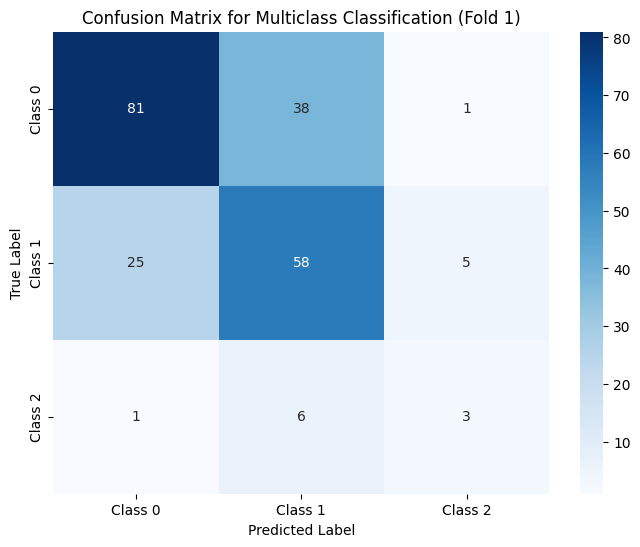

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
from pathlib import Path

# Assuming OUT_ROOT is defined in a previous cell
# If not, please define it explicitly, e.g.:
# OUT_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/HYBRID")

if 'OUT_ROOT' not in globals():
    print("OUT_ROOT variable not found. Please ensure the setup cell has been run or define OUT_ROOT explicitly.")
    # Fallback path if OUT_ROOT is not set, replace with your actual parent directory if needed
    OUT_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/HYBRID")

# Find the latest run directory
run_dirs = sorted([d for d in OUT_ROOT.iterdir() if d.is_dir() and d.name.startswith('run_')], key=os.path.getmtime, reverse=True)
if not run_dirs:
    print(f"No run directories found in {OUT_ROOT}. Please run the training script first.")
else:
    latest_run_dir = run_dirs[0]
    print(f"Analyzing results from latest run: {latest_run_dir.name}")

    # Path to the multiclass results for the first fold
    multiclass_fold_result_path = latest_run_dir / "multiclass_core_strength" / "fold_1" / "fold_result.json"

    if multiclass_fold_result_path.exists():
        with open(multiclass_fold_result_path, 'r', encoding='utf-8') as f:
            result_data = json.load(f)

        confusion_matrix_data = result_data['valid_metrics']['confusion_matrix']
        classification_report_data = result_data['valid_metrics']['classification_report']

        # Print classification report
        print("\n--- Multiclass Classification Report (Fold 1) ---")
        print(classification_report_data)

        # Plot heatmap for confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Class 0', 'Class 1', 'Class 2'],
                    yticklabels=['Class 0', 'Class 1', 'Class 2'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix for Multiclass Classification (Fold 1)')
        plt.show()
    else:
        print(f"Could not find fold_result.json at {multiclass_fold_result_path}")
        print("Please ensure the multiclass training ran successfully and generated results.")


Analyzing results from latest run: run_20260329_132916_efficientnet_b0_img256

--- Multiclass Classification Report (Fold 1) ---
              precision    recall  f1-score   support

           0       0.60      0.62      0.61        95
           1       0.53      0.61      0.57        98
           2       0.50      0.12      0.19        25

    accuracy                           0.56       218
   macro avg       0.54      0.45      0.46       218
weighted avg       0.56      0.56      0.54       218



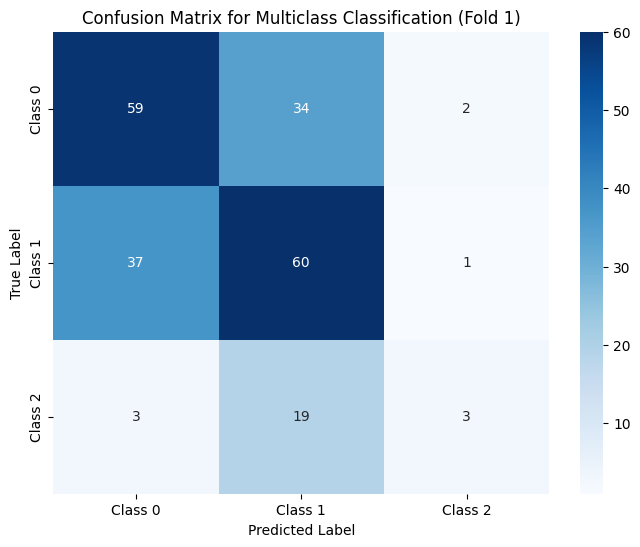

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
from pathlib import Path

# Assuming OUT_ROOT is defined in a previous cell
# If not, please define it explicitly, e.g.:
# OUT_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/HYBRID")

if 'OUT_ROOT' not in globals():
    print("OUT_ROOT variable not found. Please ensure the setup cell has been run or define OUT_ROOT explicitly.")
    # Fallback path if OUT_ROOT is not set, replace with your actual parent directory if needed
    OUT_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/HYBRID")

# Find the latest run directory
run_dirs = sorted([d for d in OUT_ROOT.iterdir() if d.is_dir() and d.name.startswith('run_')], key=os.path.getmtime, reverse=True)
if not run_dirs:
    print(f"No run directories found in {OUT_ROOT}. Please run the training script first.")
else:
    latest_run_dir = run_dirs[0]
    print(f"Analyzing results from latest run: {latest_run_dir.name}")

    # Path to the multiclass results for the first fold

    multiclass_fold_result_path = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/HYBRID/V4/multiclass_core_strength/fold_3/fold_result.json")
    if multiclass_fold_result_path.exists():
        with open(multiclass_fold_result_path, 'r', encoding='utf-8') as f:
            result_data = json.load(f)

        confusion_matrix_data = result_data['valid_metrics']['confusion_matrix']
        classification_report_data = result_data['valid_metrics']['classification_report']

        # Print classification report
        print("\n--- Multiclass Classification Report (Fold 1) ---")
        print(classification_report_data)

        # Plot heatmap for confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Class 0', 'Class 1', 'Class 2'],
                    yticklabels=['Class 0', 'Class 1', 'Class 2'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix for Multiclass Classification (Fold 1)')
        plt.show()
    else:
        print(f"Could not find fold_result.json at {multiclass_fold_result_path}")
        print("Please ensure the multiclass training ran successfully and generated results.")

Analyzing results from latest run: run_20260329_132916_efficientnet_b0_img256

--- Multiclass Classification Report (Fold 1) ---
              precision    recall  f1-score   support

           0       0.79      0.67      0.73        95
           1       0.60      0.68      0.64        98
           2       0.38      0.40      0.39        25

    accuracy                           0.65       218
   macro avg       0.59      0.59      0.59       218
weighted avg       0.66      0.65      0.65       218



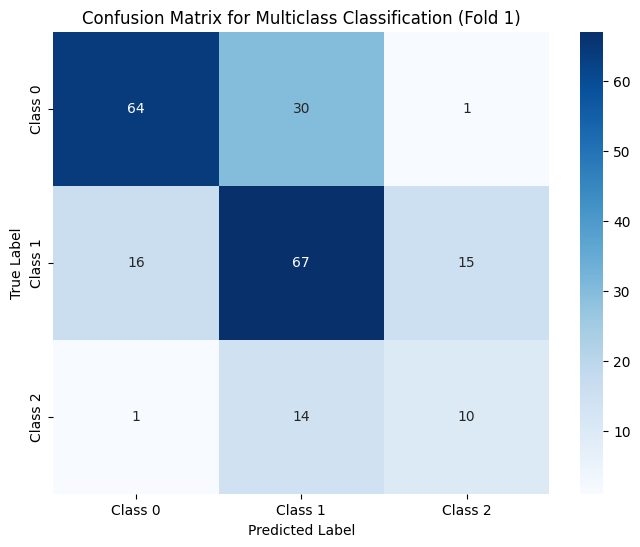

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
from pathlib import Path

# Assuming OUT_ROOT is defined in a previous cell
# If not, please define it explicitly, e.g.:
# OUT_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/HYBRID")

if 'OUT_ROOT' not in globals():
    print("OUT_ROOT variable not found. Please ensure the setup cell has been run or define OUT_ROOT explicitly.")
    # Fallback path if OUT_ROOT is not set, replace with your actual parent directory if needed
    OUT_ROOT = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/HYBRID")

# Find the latest run directory
run_dirs = sorted([d for d in OUT_ROOT.iterdir() if d.is_dir() and d.name.startswith('run_')], key=os.path.getmtime, reverse=True)
if not run_dirs:
    print(f"No run directories found in {OUT_ROOT}. Please run the training script first.")
else:
    latest_run_dir = run_dirs[0]
    print(f"Analyzing results from latest run: {latest_run_dir.name}")

    # Path to the multiclass results for the first fold

    multiclass_fold_result_path = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/5. 추출+CNN Pipeline/step3_roi_applied_cnn/BASIC/run_20260329_084844_efficientnet_b0_img256/multiclass_core_strength/fold_3/fold_result.json")
    if multiclass_fold_result_path.exists():
        with open(multiclass_fold_result_path, 'r', encoding='utf-8') as f:
            result_data = json.load(f)

        confusion_matrix_data = result_data['valid_metrics']['confusion_matrix']
        classification_report_data = result_data['valid_metrics']['classification_report']

        # Print classification report
        print("\n--- Multiclass Classification Report (Fold 1) ---")
        print(classification_report_data)

        # Plot heatmap for confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Class 0', 'Class 1', 'Class 2'],
                    yticklabels=['Class 0', 'Class 1', 'Class 2'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix for Multiclass Classification (Fold 1)')
        plt.show()
    else:
        print(f"Could not find fold_result.json at {multiclass_fold_result_path}")
        print("Please ensure the multiclass training ran successfully and generated results.")